In [1]:
import os
import subprocess
from pathlib import Path

PROJECT_ROOT = Path('/home/akhil/Invitation_research')
FONT_DIR = PROJECT_ROOT / 'static' / 'fonts'
OUTPUT_DIR = PROJECT_ROOT / 'z_research'
FONTCONFIG_FILE = Path('/tmp/invitation-fontconfig.xml')
FONTCONFIG_CACHE = Path('/tmp/fontconfig-cache')
FONTCONFIG_CACHE.mkdir(exist_ok=True)

gujarati_font = FONT_DIR / 'AnekGujarati_Expanded-Regular.ttf'
english_font = FONT_DIR / 'GreatVibes-Regular.ttf'

fontconfig_xml = f"""<?xml version="1.0"?>
<!DOCTYPE fontconfig SYSTEM "fonts.dtd">
<fontconfig>
  <include ignore_missing="yes">/etc/fonts/fonts.conf</include>
  <dir>{FONT_DIR}</dir>
  <cachedir>{FONTCONFIG_CACHE}</cachedir>
</fontconfig>
"""
FONTCONFIG_FILE.write_text(fontconfig_xml)
os.environ['FONTCONFIG_FILE'] = str(FONTCONFIG_FILE)

subprocess.run(
    ['fc-cache', '-f', str(FONT_DIR)],
    check=False,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)

import cairo
import gi
from PIL import Image, ImageFont
from IPython.display import display

gi.require_version('Pango', '1.0')
gi.require_version('PangoCairo', '1.0')
from gi.repository import Pango, PangoCairo

print(f'Using fonts from: {FONT_DIR}')


Using fonts from: /home/akhil/Invitation_research/static/fonts


In [2]:
def font_family(font_file: str | Path) -> str:
    return ImageFont.truetype(str(font_file), size=16).getname()[0]


def rgb(hex_color: str) -> tuple[float, float, float]:
    value = hex_color.lstrip('#')
    return tuple(int(value[i:i + 2], 16) / 255 for i in (0, 2, 4))


def pango_layout(ctx, text: str, family: str, size: int, max_width: int | None = None, align: str = 'left'):
    layout = PangoCairo.create_layout(ctx)
    layout.set_text(text, -1)

    desc = Pango.FontDescription()
    desc.set_family(family)
    desc.set_size(size * Pango.SCALE)
    layout.set_font_description(desc)

    if max_width:
        layout.set_width(max_width * Pango.SCALE)
        layout.set_wrap(Pango.WrapMode.WORD_CHAR)

    layout.set_alignment({
        'left': Pango.Alignment.LEFT,
        'center': Pango.Alignment.CENTER,
        'right': Pango.Alignment.RIGHT,
    }.get(align, Pango.Alignment.LEFT))
    layout.set_auto_dir(True)
    return layout


def render_text_layers_png(
    layers: list[dict],
    output: str | Path,
    canvas_size: tuple[int, int] = (800, 600),
):
    width, height = canvas_size
    surface = cairo.ImageSurface(cairo.FORMAT_ARGB32, width, height)
    # FORMAT_ARGB32 initialises to all-zero (fully transparent) — no paint needed
    ctx = cairo.Context(surface)

    for layer in layers:
        text = layer["text"]
        font_file = layer["font_file"]
        family = font_family(font_file)
        size = layer.get("size", 48)
        color = layer.get("color", "#111111")
        x = layer.get("x", 0)
        y = layer.get("y", 0)
        max_width = layer.get("max_width")
        align = layer.get("align", "left")

        layout = pango_layout(ctx, text, family, size, max_width, align)

        ctx.set_source_rgba(*rgb(color), 1)
        ctx.move_to(x, y)
        PangoCairo.show_layout(ctx, layout)

    output = Path(output)
    surface.write_to_png(str(output))
    return output


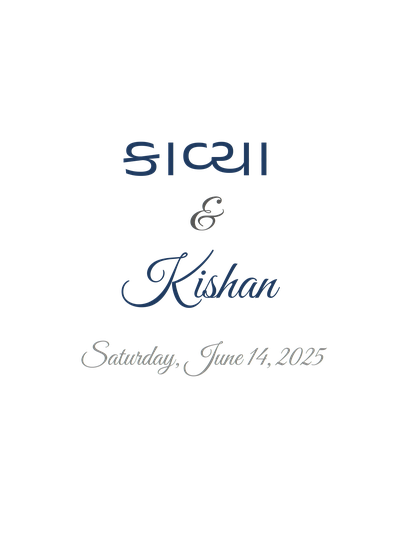

HQ text: 1424x2008  coord_scale=3.596
Saved: /home/akhil/Invitation_research/z_research/invitation_on_video.mp4


In [3]:
from IPython.display import Video

BASE_VIDEO = PROJECT_ROOT / 'static' / 'template_media' / 'White Watercolor Elegant Wedding Invitation Video.mp4'

# ── Invitation config ──────────────────────────────────────────────────────────
invitation = {
    "canvas_size": (396, 558),
    "layers": [
        {
            "text": "કાવ્યા",
            "font_file": gujarati_font,
            "size": 42,
            "color": "#1f3a5f",
            "x": 120,
            "y": 120,
            "align": "left",
        },
        {
            "text": "&",
            "font_file": english_font,
            "size": 34,
            "color": "#555555",
            "x": 190,
            "y": 190,
        },
        {
            "text": "Kishan",
            "font_file": english_font,
            "size": 42,
            "color": "#1f3a5f",
            "x": 120,
            "y": 250,
        },
        {
            "text": "Saturday, June 14, 2025",
            "font_file": english_font,
            "size": 22,
            "color": "#888888",
            "x": 80,
            "y": 340,
            "align": "left",
        },
    ],
}

# ── Parameters ─────────────────────────────────────────────────────────────────
canvas_w, canvas_h = invitation["canvas_size"]
video_w,  video_h  = canvas_w, canvas_h   # base video is already 396x558
fps         = 60
duration    = 5                            # match base video length
total_frames = fps * duration
scale_start = 0.90
scale_end   = 0.55
quality_scale = 4                          # text rendered at 4x for sharp downscale

# ── Render HQ text PNG once ────────────────────────────────────────────────────
# Render at the largest display size text will ever appear (scale_start frame).
# Every animation frame is then a downscale → always sharp, never blurry.
max_disp_w = round(video_w * scale_start)
max_disp_h = round(max_disp_w * canvas_h / canvas_w)
hq_w = max_disp_w * quality_scale
hq_h = max_disp_h * quality_scale

coord_scale = hq_w / canvas_w
hq_layers = []
for layer in invitation["layers"]:
    hq_layer = {**layer,
                "x":    round(layer["x"]    * coord_scale),
                "y":    round(layer["y"]    * coord_scale),
                "size": round(layer["size"] * coord_scale)}
    if layer.get("max_width"):
        hq_layer["max_width"] = round(layer["max_width"] * coord_scale)
    hq_layers.append(hq_layer)

hq_png_path = OUTPUT_DIR / "invitation_hq.png"
render_text_layers_png(hq_layers, hq_png_path, canvas_size=(hq_w, hq_h))
text_image = Image.open(hq_png_path).convert("RGBA")

preview = text_image.resize(invitation["canvas_size"], Image.Resampling.LANCZOS)
display(preview)
print(f"HQ text: {hq_w}x{hq_h}  coord_scale={coord_scale:.3f}")

# ── Decode base video frames as raw RGB24 ──────────────────────────────────────
frame_bytes = video_w * video_h * 3   # bytes per RGB24 frame

decode = subprocess.Popen([
    "ffmpeg", "-i", str(BASE_VIDEO),
    "-vf", f"fps={fps},scale={video_w}:{video_h}",
    "-f", "rawvideo", "-pix_fmt", "rgb24", "-",
], stdout=subprocess.PIPE, stderr=subprocess.DEVNULL)

# ── Encode output ──────────────────────────────────────────────────────────────
output_path = OUTPUT_DIR / "invitation_on_video.mp4"

encode = subprocess.Popen([
    "ffmpeg", "-y",
    "-framerate", str(fps),
    "-f", "image2pipe", "-vcodec", "png", "-i", "-",
    "-c:v", "libx264", "-pix_fmt", "yuv420p", "-crf", "18",
    "-movflags", "+faststart",
    str(output_path),
], stdin=subprocess.PIPE, stderr=subprocess.PIPE)

# ── Frame loop ─────────────────────────────────────────────────────────────────
for frame_num in range(total_frames):
    # Read one base video frame (RGB24)
    raw = decode.stdout.read(frame_bytes)
    if len(raw) < frame_bytes:
        break
    base_frame = Image.frombytes("RGB", (video_w, video_h), raw).convert("RGBA")

    # Ease-out cubic zoom: starts at scale_start, settles at scale_end
    progress = frame_num / max(total_frames - 1, 1)
    t = 1 - (1 - progress) ** 3
    scale = scale_start + (scale_end - scale_start) * t

    disp_w = round(video_w * scale)
    disp_h = round(disp_w * canvas_h / canvas_w)

    # Downscale HQ text to display size (always a downscale → sharp)
    scaled_text = text_image.resize((disp_w, disp_h), Image.Resampling.LANCZOS)

    # Composite text centred on base video frame
    x = (video_w - disp_w) // 2
    y = (video_h - disp_h) // 2
    base_frame.paste(scaled_text, (x, y), scaled_text)

    base_frame.convert("RGB").save(encode.stdin, format="PNG")

decode.stdout.close()
decode.wait()
encode.stdin.close()
stderr = encode.stderr.read().decode()
if encode.wait() != 0:
    print(stderr)
    raise RuntimeError("FFmpeg encode failed")

print(f"Saved: {output_path}")
display(Video(str(output_path), embed=True, width=396, height=558))
